### Exploratory analysis of how inequalities are reflected in Olympic Games over time

#### Short Notes

- The dataset goes from **1896 to 2016**
- This notebook studies how inequalities appear in Olympic history through three main angles:

1. **Gender inequalities**  
2. **Geopolitical inequalities and disruptions**  
3. **Evolution of disciplines and structural inequalities**  

In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from pathlib import Path
import plotly.express as px

sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", 100)

In [2]:
data_path = Path("../../data/olympics.csv")
olympics = pd.read_csv(data_path)

#### Basic Details

In [3]:
print("Entries in Olympics Dataset:", olympics.shape[0])
print("Olympics Dataset Columns:", ", ".join(olympics.columns))
olympics.head()

Entries in Olympics Dataset: 271116
Olympics Dataset Columns: id, name, sex, age, height, weight, team, noc, games, year, season, city, sport, event, medal, region, notes, gdp_per_capita


,id,name,sex,age,height,weight,team,noc,games,year,season,city,sport,event,medal,region,notes,gdp_per_capita
0,1,A Dijiang,M,24.0,180.0,80.0,China,CHN,1992 Summer,1992,Summer,Barcelona,Basketball,Basketball Men's Basketball,NaN,China,NaN,367.822652
1,2,A Lamusi,M,23.0,170.0,60.0,China,CHN,2012 Summer,2012,Summer,London,Judo,Judo Men's Extra-Lightweight,NaN,China,NaN,6405.057424
2,3,Gunnar Nielsen Aaby,M,24.0,NaN,NaN,Denmark,DEN,1920 Summer,1920,Summer,Antwerpen,Football,Football Men's Football,NaN,Denmark,NaN,NaN
3,4,Edgar Lindenau Aabye,M,34.0,NaN,NaN,Denmark/Sweden,DEN,1900 Summer,1900,Summer,Paris,Tug-Of-War,Tug-Of-War Men's Tug-Of-War,Gold,Denmark,NaN,NaN
4,5,Christine Jacoba Aaftink,F,21.0,185.0,82.0,Netherlands,NED,1988 Winter,1988,Winter,Calgary,Speed Skating,Speed Skating Women's 500 metres,NaN,Netherlands,NaN,17770.616238


In [10]:
print("Earliest Year:", olympics["year"].min())
print("Latest Year:", olympics["year"].max())
print("Number of Seasons:", olympics["season"].nunique())
print("Number of Sports:", olympics["sport"].nunique())
print("Number of Disciplines:", olympics["discipline"].nunique())
print("Number of Events:", olympics["event"].nunique())
print("Number of Countries:", olympics["country"].nunique())

Earliest Year: 1896
Latest Year: 2014
Number of Seasons: 2
Number of Sports: 48
Number of Disciplines: 80
Number of Events: 733
Number of Countries: 130


#### Basic Statistics: Gender

In [28]:
gender_time = olympics.groupby(['year', 'gender']).size().reset_index(name='count')

# Create all possible combinations
all_years = sorted(gender_time['year'].unique())
all_genders = ['Men', 'Women']

full_index = pd.MultiIndex.from_product(
    [all_years, all_genders],
    names=['year', 'gender']
)

gender_time = (
    gender_time
    .set_index(['year', 'gender'])
    .reindex(full_index, fill_value=0)
    .reset_index()
)

fig_gender = px.bar(
    gender_time,
    x='gender',
    y='count',
    color='gender',
    animation_frame='year',
    range_y=[0, gender_time['count'].max() + 50],
    title='The Path to Parity: Gender Medal Records Over Time',
    template='ggplot2',
    color_discrete_map={
        'Men': '#ADD8E6',     # pastel blue
        'Women': '#FFB6C1'    # pastel pink
    }
)

fig_gender.update_layout(
    xaxis_title='Gender',
    yaxis_title='Number of Medal Records'
)

fig_gender.show()

In [12]:
gender_share = (
    olympics.groupby(["year", "gender"])
    .size()
    .unstack(fill_value=0)
)

gender_share["total"] = gender_share.sum(axis=1)
gender_share["women_share"] = 100 * gender_share["Women"] / gender_share["total"]

print("Women's Share of Medal Records by Year:")
gender_share[["Women", "Men", "women_share"]].tail(15)

Women's Share of Medal Records by Year:


gender,Women,Men,women_share
year,,,
1980,480,1125,29.907
1984,540,1141,32.124
1988,598,1212,33.039
1992,699,1331,34.433
1994,111,232,32.362
1996,777,1082,41.797
1998,189,258,42.282
2000,889,1126,44.119
2002,208,273,43.243


#### Basic Statistics: Gender Inequality by Sport

In [24]:
sport_gender = (
    olympics.groupby(["sport", "gender"])
    .size()
    .unstack(fill_value=0)
)

sport_gender["total"] = sport_gender.sum(axis=1)
sport_gender["women_share"] = 100 * sport_gender["Women"] / sport_gender["total"]

sport_gender.sort_values("women_share").head(10)

gender,Men,Women,total,women_share
sport,,,,
Basque Pelota,4,0,4,0.000
Baseball,335,0,335,0.000
Cricket,24,0,24,0.000
Croquet,8,0,8,0.000
Roque,3,0,3,0.000
Lacrosse,59,0,59,0.000
Rackets,10,0,10,0.000
Polo,66,0,66,0.000
Jeu de paume,3,0,3,0.000


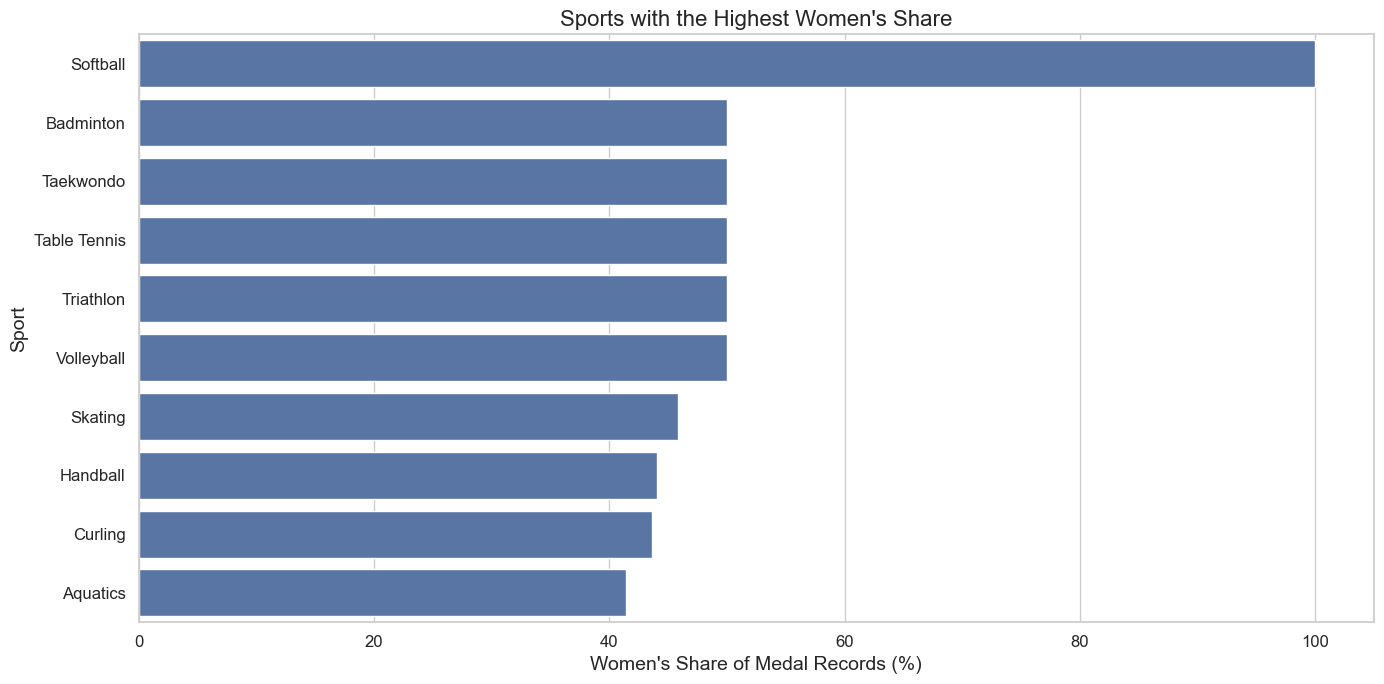

In [25]:
female_balanced = sport_gender.sort_values("women_share", ascending=False).head(10).reset_index()

plt.figure(figsize=(14, 7))
sns.barplot(data=female_balanced, x="women_share", y="sport")
plt.title("Sports with the Highest Women's Share", fontsize=16)
plt.xlabel("Women's Share of Medal Records (%)", fontsize=14)
plt.ylabel("Sport", fontsize=14)
plt.xticks(fontsize=12)
plt.yticks(fontsize=12)
plt.tight_layout()
plt.show()

#### Basic Statistics: Sports and Disciplines

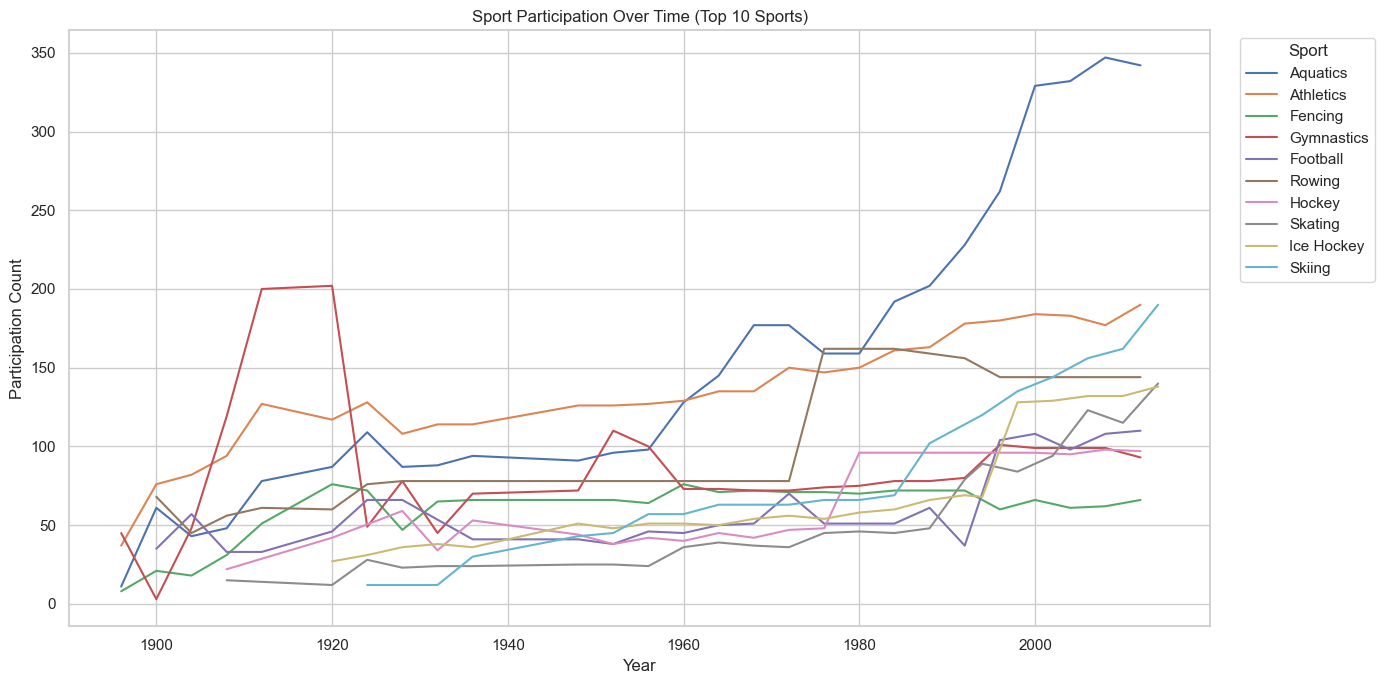

In [33]:
## Sport participation over time

sport_year = (
    olympics.groupby(["year", "sport"])
    .size()
    .reset_index(name="participation_count")
)

# Top sports only (cleaner plot)
top_sports = (
    sport_year.groupby("sport")["participation_count"]
    .sum()
    .nlargest(10)
    .index
)

sport_year_top = sport_year[sport_year["sport"].isin(top_sports)]

plt.figure(figsize=(14,7))
sns.lineplot(
    data=sport_year_top,
    x="year",
    y="participation_count",
    hue="sport"
)
plt.title("Sport Participation Over Time (Top 10 Sports)")
plt.xlabel("Year")
plt.ylabel("Participation Count")
plt.legend(title="Sport", bbox_to_anchor=(1.02,1))
plt.tight_layout()
plt.show()

In [13]:
year_summary = (
    olympics.groupby("year")
    .agg(
        sports=("sport", "nunique"),
        disciplines=("discipline", "nunique"),
        events=("event", "nunique"),
        countries=("country", "nunique")
    )
    .reset_index()
)

year_summary.head()

,year,sports,disciplines,events,countries
0,1896,9,10,43,10
1,1900,19,20,78,18
2,1904,16,17,92,9
3,1908,22,25,103,16
4,1912,14,18,95,16


#### Basic Statistics: Geopolitical Visibility

In [19]:
country_year = (
    olympics.groupby(["year", "country"])
    .size()
    .reset_index(name="count")
)

print("Countries with the most medal records:")
olympics["country"].value_counts().head(15)

Countries with the most medal records:


country
United States     5238
United Kingdom    1799
Germany           1665
France            1548
Italy             1488
Sweden            1477
Canada            1274
Australia         1204
Hungary           1091
Russia            1031
Norway            1011
Netherlands        973
Finland            890
China              889
Japan              851
Name: count, dtype: int64

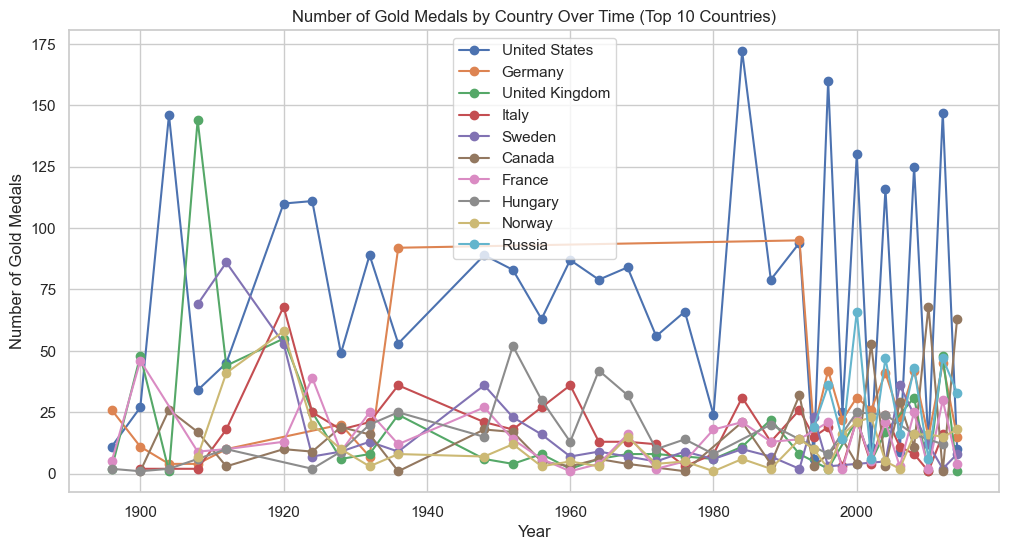

In [29]:
# Select only gold medals
gold_medals = olympics[olympics['medal'] == 'Gold']

# Count gold medals per year and country
gold_year_country = (
    gold_medals
    .groupby(['year', 'country'])
    .size()
    .reset_index(name='count')
)

# Find top 10 countries by total gold medals
top_countries = (
    gold_year_country
    .groupby('country')['count']
    .sum()
    .sort_values(ascending=False)
    .head(10)
    .index
)

gold_top = gold_year_country[gold_year_country['country'].isin(top_countries)]

plt.figure(figsize=(12,6))

for country in top_countries:
    country_data = gold_top[gold_top['country'] == country]
    plt.plot(country_data['year'], country_data['count'], marker='o', label=country)

plt.title("Number of Gold Medals by Country Over Time (Top 10 Countries)")
plt.xlabel("Year")
plt.ylabel("Number of Gold Medals")
plt.legend()
plt.show()

In [31]:
fig = px.line(
    gold_top,
    x='year',
    y='count',
    color='country',
    title='Gold Medals by Country Over Time (Top 10 Countries)'
)

fig.show()

#### Basic Statistics: GDP

In [32]:
## GDP per capita vs medal count

medals_df = olympics[olympics["medal"].notna()].copy()

country_medals = (
    medals_df.groupby(["country", "gdp_per_capita", "population"])
    .size()
    .reset_index(name="medal_count")
)

fig = px.scatter(
    country_medals,
    x="gdp_per_capita",
    y="medal_count",
    hover_name="country",         
    size="population",             # bubble size = population
    title="GDP per Capita vs Medal Count",
    labels={
        "gdp_per_capita": "GDP per Capita (USD)",
        "medal_count": "Total Medal Count"
    }
)

fig.show()

In [35]:
medals_df = olympics[olympics["medal"].notna()].copy()

country_medals = (
    medals_df
    .groupby(["year", "country", "gdp_per_capita", "population"])
    .size()
    .reset_index(name="medal_count")
)

fig = px.scatter(
    country_medals,
    x="gdp_per_capita",
    y="medal_count",
    animation_frame="year",   # key change
    hover_name="country",
    size="population",
    title="GDP per Capita vs Medal Count Over Time",
    labels={
        "gdp_per_capita": "GDP per Capita (USD)",
        "medal_count": "Total Medal Count",
        "year": "Year"
    }
)

fig.show()

#### Basic Statistics: Medal Type and Age

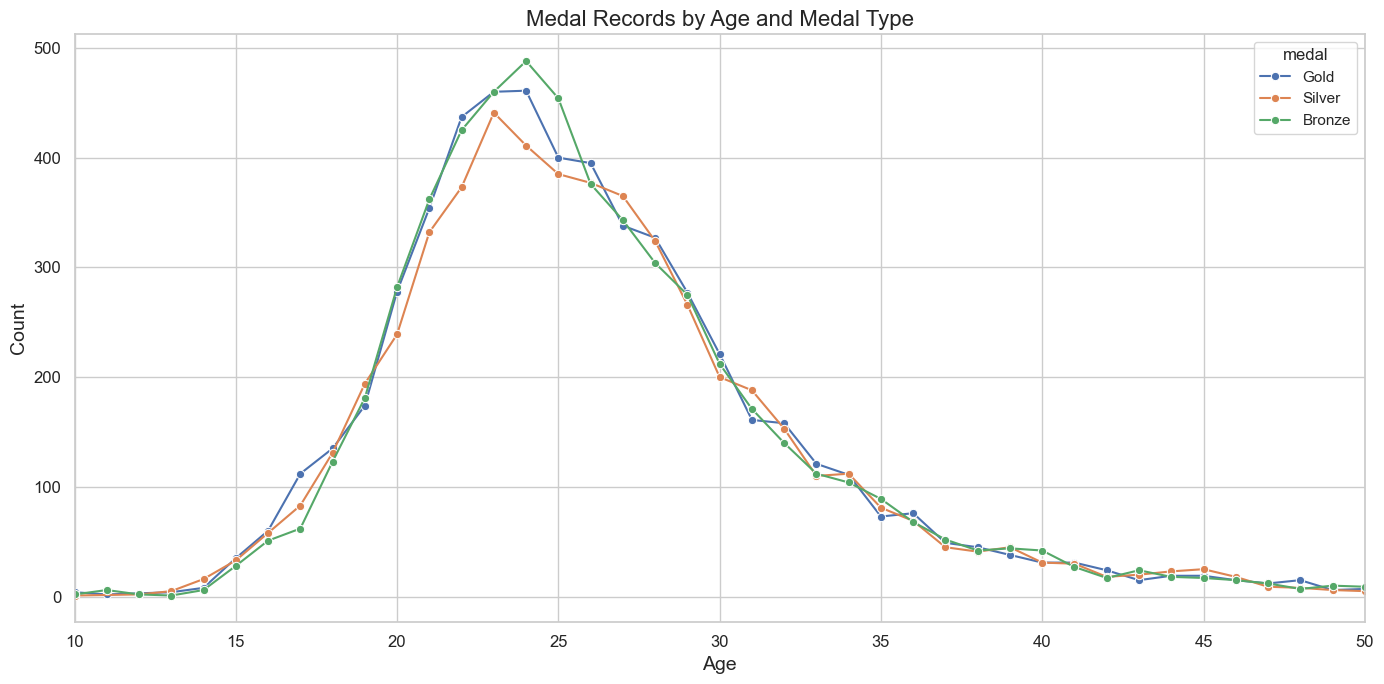

In [22]:
medals_age = olympics.dropna(subset=["age"]).copy()

age_medal = (
    medals_age.groupby(["age", "medal"])
    .size()
    .reset_index(name="count")
)

plt.figure(figsize=(14, 7))
sns.lineplot(data=age_medal, x="age", y="count", hue="medal", marker="o")
plt.title("Medal Records by Age and Medal Type", fontsize=16)
plt.xlabel("Age", fontsize=14)
plt.ylabel("Count", fontsize=14)
plt.xlim(10, 50)
plt.xticks(fontsize=12)
plt.yticks(fontsize=12)
plt.tight_layout()
plt.show()